In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import os
import cv2
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from tqdm import *

In [3]:
image_path = os.path.join("/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D1/CXR_png")
mask_path = os.path.join("/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D1/","masks/")

In [4]:
images = os.listdir(image_path)
mask = os.listdir(mask_path)
mask = [fName.split(".png")[0] for fName in mask]
image_file_name = [fName.split("_mask")[0] for fName in mask]

In [5]:
check = [i for i in mask if "mask" in i]
print("Total mask that has modified name:",len(check))

Total mask that has modified name: 566


In [6]:
testing_files = set(os.listdir(image_path)) & set(os.listdir(mask_path))
training_files = check

def getData(X_shape, flag = "test"):
    im_array = []
    mask_array = []

    if flag == "test":
        for i in tqdm(testing_files):
            im = cv2.resize(cv2.imread(os.path.join(image_path,i)),(X_shape,X_shape))[:,:,0]
            mask = cv2.resize(cv2.imread(os.path.join(mask_path,i)),(X_shape,X_shape))[:,:,0]

            im_array.append(im)
            mask_array.append(mask)

        return im_array,mask_array

    if flag == "train":
        for i in tqdm(training_files):
            im = cv2.resize(cv2.imread(os.path.join(image_path,i.split("_mask")[0]+".png")),(X_shape,X_shape))[:,:,0]
            mask = cv2.resize(cv2.imread(os.path.join(mask_path,i+".png")),(X_shape,X_shape))[:,:,0]

            im_array.append(im)
            mask_array.append(mask)

        return im_array,mask_array

In [7]:
# Load training and testing data
dim = 256*2
X_train,y_train = getData(dim,flag="train")
X_test, y_test = getData(dim)

100%|██████████| 138/138 [02:56<00:00,  1.28s/it]


In [8]:
X_train = np.array(X_train).reshape(len(X_train),dim,dim,1)
y_train = np.array(y_train).reshape(len(y_train),dim,dim,1)
X_test = np.array(X_test).reshape(len(X_test),dim,dim,1)
y_test = np.array(y_test).reshape(len(y_test),dim,dim,1)
assert X_train.shape == y_train.shape
assert X_test.shape == y_test.shape
# images = np.concatenate((X_train,X_test),axis=0)
# mask  = np.concatenate((y_train,y_test),axis=0)

In [9]:
def unet(input_size=(256,256,1)):
    inputs = Input(input_size)

    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    return Model(inputs=[inputs], outputs=[conv10])

#### Compile and train the Unet Model

In [10]:
model = unet(input_size=(512,512,1))
model.load_weights('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/model.h5')

Enter the path of the image file: /content/drive/MyDrive/Major_Project_Pneumonia_Detection/last/data/test_image/img4.png
1/1 [==============================] - 0s 18ms/step


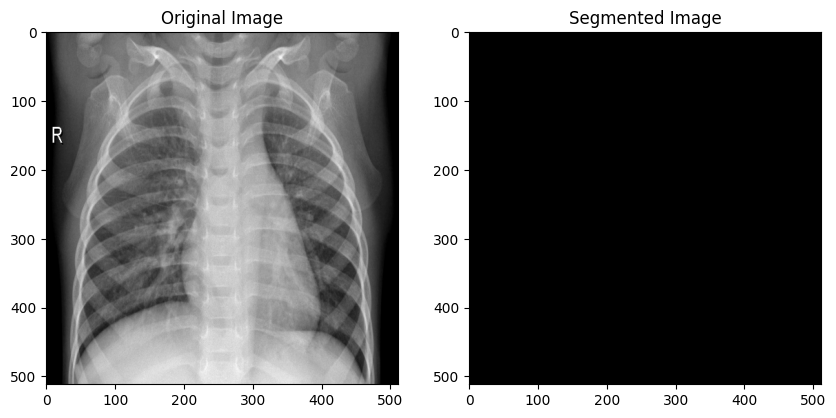

In [46]:
import matplotlib.pyplot as plt

# Preprocess the uploaded image
def preprocess_image(image):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize the image to match the input size of the model (512x512)
    resized_image = cv2.resize(image, (512, 512))

    # Normalize the pixel values to be in the range [0, 1]
    normalized_image = resized_image / 255.0

    # Expand the dimensions to match the input shape of the model
    preprocessed_image = np.expand_dims(normalized_image, axis=-1)

    return preprocessed_image

# Prediction function
def predict_segmentation(image):
    # Preprocess the image
    preprocessed_image = preprocess_image(image)

    # Perform prediction
    prediction = model.predict(np.array([preprocessed_image]))

    # Threshold the prediction to get binary mask
    thresholded_prediction = (prediction > 0.5).astype(np.uint8)

    return thresholded_prediction

# Function to process uploaded image and display result
def process_and_display_image(file_path):
    try:
        # Read the image
        image = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

        # Perform segmentation
        segmented_image = predict_segmentation(image)

        # Check if pneumonia is detected
        pneumonia_detected = np.max(segmented_image) == 1

        # Display the result using Matplotlib
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Original Image')
        axes[1].imshow(segmented_image.squeeze(), cmap='gray')
        axes[1].set_title('Segmented Image')
        plt.show()


    except Exception as e:
        print(f"Error processing image: {e}")

# Function to handle file input
def get_file_path():
    file_path = input("Enter the path of the image file: ")
    process_and_display_image(file_path)

# Get file path from user and process image
get_file_path()

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Assume the model is loaded and available as `model`
# model = load_your_trained_model()

# Preprocess the uploaded image
def preprocess_image(image):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize the image to match the input size of the model (512x512)
    resized_image = cv2.resize(image, (512, 512))

    # Normalize the pixel values to be in the range [0, 1]
    normalized_image = resized_image / 255.0

    # Expand the dimensions to match the input shape of the model
    preprocessed_image = np.expand_dims(normalized_image, axis=-1)

    return preprocessed_image

# Prediction function
def predict_segmentation(image):
    # Preprocess the image
    preprocessed_image = preprocess_image(image)

    # Perform prediction
    prediction = model.predict(np.array([preprocessed_image]))

    # Threshold the prediction to get binary mask
    thresholded_prediction = (prediction > 0.5).astype(np.uint8)

    return thresholded_prediction

# Function to process uploaded image and display result
def process_and_display_image(file_path):
    try:
        # Read the image
        image = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

        # Perform segmentation
        segmented_image = predict_segmentation(image)

        # Check if pneumonia is detected
        pneumonia_detected = np.max(segmented_image) == 0

        # Display the result using Matplotlib
        if not pneumonia_detected:  # If pneumonia is not detected, display segmented image
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(image, cmap='gray')
            axes[0].set_title('Original Image')
            axes[1].imshow(segmented_image.squeeze(), cmap='gray')
            axes[1].set_title('Segmented Image')
            plt.show()
        else:
            print("Pneumonia detected, no segmented image to display for normal CXR.")

    except Exception as e:
        print(f"Error processing image: {e}")

# Function to handle file input
def get_file_path():
    file_path = input("Enter the path of the image file: ")
    process_and_display_image(file_path)

# Get file path from user and process image
get_file_path()

Enter the path of the image file: /content/drive/MyDrive/Major_Project_Pneumonia_Detection/last/data/test_image/img7.png
1/1 [==============================] - 0s 21ms/step
Pneumonia detected, no segmented image to display for normal CXR.
